# Report

https://docs.google.com/document/d/1fpae88uEObBtORFKeBIZD24gYnZo1yZyYRir41VorOI/edit?usp=sharing

# Imports

# Load dataset

In [1]:
!pip install -q librosa transformers torchaudio datasets soundfile audiomentations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import torch
import torchaudio
from pathlib import Path
import logging
import datasets as ds_module
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from tqdm import tqdm
!pip install -q funasr modelscope
from funasr import AutoModel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, TensorDataset, Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
import warnings
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
import torch.nn.functional as F
warnings.filterwarnings('ignore')
from sklearn.metrics import recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
import shutil
from huggingface_hub import snapshot_download

print(f"torch: {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")
print(f"librosa: {librosa.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 18.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you h

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


torch: 2.10.0+cu128
torchaudio: 2.10.0+cu128
librosa: 0.11.0
GPU available: True
GPU: Tesla T4


In [2]:
ROOT = snapshot_download(
    "OlhaHavryliuk/UA-SER",
    repo_type="dataset",
    allow_patterns=["clips/*", "dataset.csv"],
)

CLIPS_DIR = "/kaggle/working/clips"
os.makedirs(CLIPS_DIR, exist_ok=True)
src_clips = os.path.join(ROOT, "clips")
for fn in os.listdir(src_clips):
    dst = os.path.join(CLIPS_DIR, fn)
    if not os.path.exists(dst):
        shutil.copy(os.path.join(src_clips, fn), dst)

print("ROOT:", ROOT)
print("Clips staged:", len(os.listdir(CLIPS_DIR)), "->", CLIPS_DIR)

Fetching 953 files:   0%|          | 0/953 [00:00<?, ?it/s]

ROOT: /root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9
Clips staged: 952 -> /kaggle/working/clips


In [3]:
csv_path = os.path.join(ROOT, "dataset.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Head:")
print(df.head())
print("Emotion distribution:")
print(df['emotion'].value_counts())
print("Split distribution:")
print(df['split'].value_counts())

Shape: (952, 6)
Columns: ['filename', 'emotion', 'duration_seconds', 'text', 'speaker_id', 'split']
Head:
      filename emotion  duration_seconds                              text  \
0  s_001_1.wav     sad              1.86     Якщо в тебе щось не виходить,   
1  s_002_1.wav     sad              1.54      Але я тебе ніколи не бачила.   
2  s_003_0.wav     sad              1.72       Якраз для дівчаток. Тримай.   
3  s_004_1.wav     sad              2.08  Я цих 700 грн ділила на 30 днів.   
4  s_005_1.wav     sad              1.54               Нічого не відчуваю.   

   speaker_id  split  
0         166  train  
1         107   test  
2          58  train  
3          37  train  
4         176  train  
Emotion distribution:
emotion
angry      259
happy      244
sad        227
neutral    222
Name: count, dtype: int64
Split distribution:
split
train    771
test     181
Name: count, dtype: int64


In [4]:
print("Done:", len(os.listdir(CLIPS_DIR)), "files in", CLIPS_DIR)

Done: 952 files in /kaggle/working/clips


# EDA

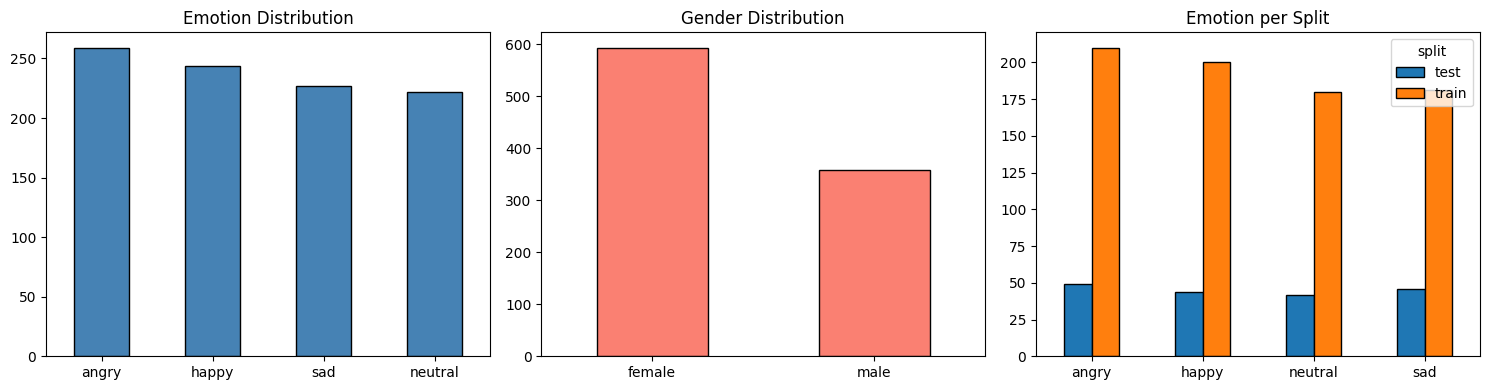

Duration stats (seconds):
count    952.00
mean       2.07
std        0.75
min        0.52
25%        1.53
50%        1.99
75%        2.55
max        5.50
Name: duration_seconds, dtype: float64


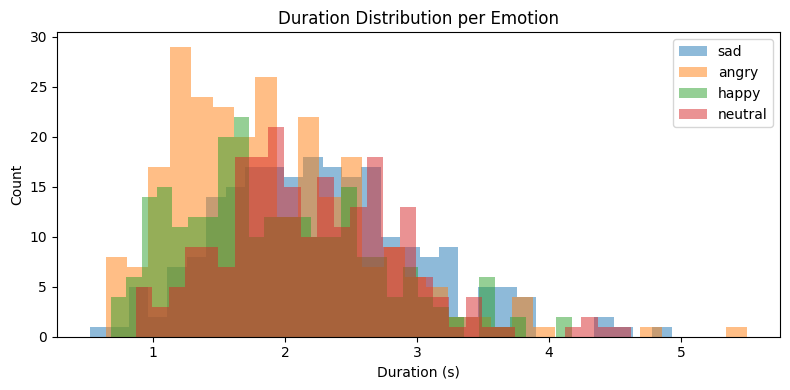

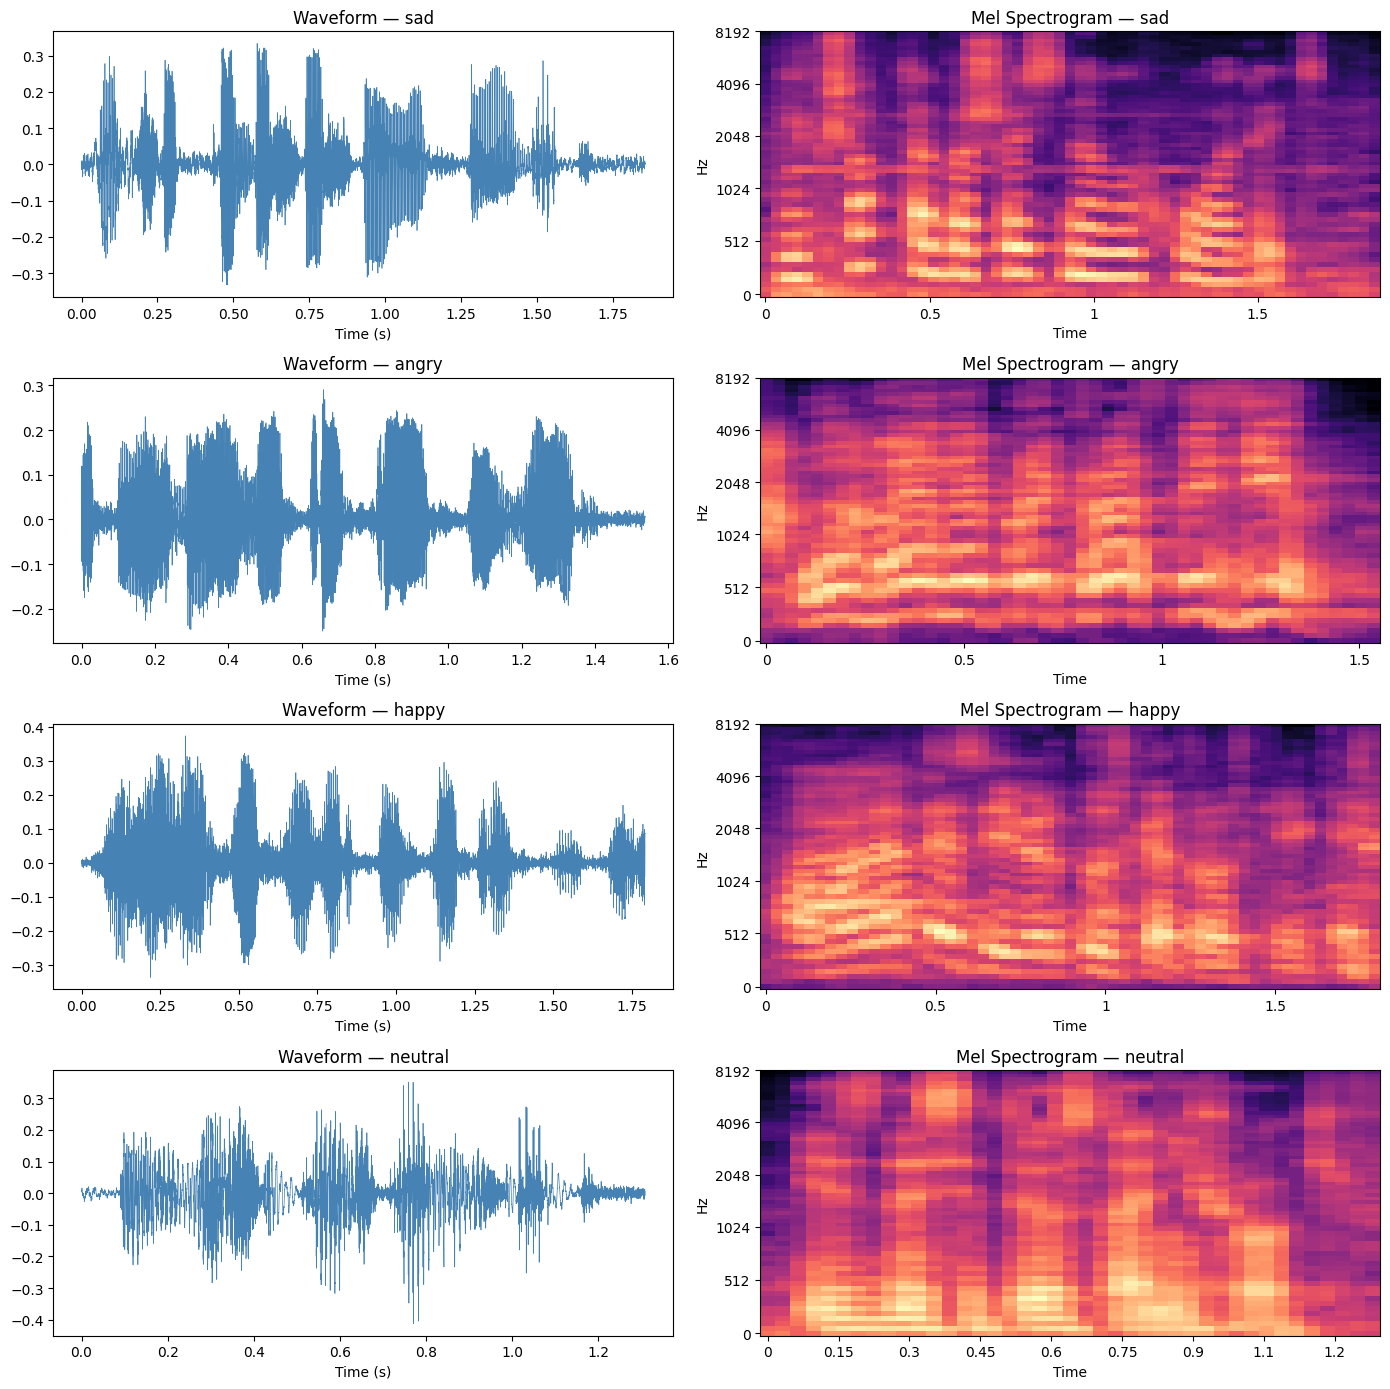


Gender x Emotion:
gender   female  male
emotion              
angry       141   118
happy       171    73
neutral      94   128
sad         187    40

Gender x Split:
gender  female  male
split               
test        98    83
train      495   276


In [6]:
CLIPS_DIR = "/kaggle/working/clips"

df['gender'] = df['filename'].str.extract(r'_(\d)\.wav$')[0].astype(int).map({0: 'male', 1: 'female'})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['emotion'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Emotion Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['gender'].value_counts().plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

df.groupby(['emotion', 'split']).size().unstack().plot(kind='bar', ax=axes[2], edgecolor='black')
axes[2].set_title('Emotion per Split')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

print("Duration stats (seconds):")
print(df['duration_seconds'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
for emotion in df['emotion'].unique():
    subset = df[df['emotion'] == emotion]['duration_seconds']
    ax.hist(subset, bins=30, alpha=0.5, label=emotion)
ax.set_title('Duration Distribution per Emotion')
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('eda_duration.png', dpi=150)
plt.show()

emotions = df['emotion'].unique()
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, emotion in enumerate(emotions):
    sample = df[df['emotion'] == emotion].iloc[0]
    y, sr = librosa.load(f"{CLIPS_DIR}/{sample['filename']}", sr=16000)
    
    axes[i, 0].plot(np.linspace(0, len(y)/sr, len(y)), y, color='steelblue', linewidth=0.5)
    axes[i, 0].set_title(f'Waveform — {emotion}')
    axes[i, 0].set_xlabel('Time (s)')
    
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64), ref=np.max)
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'Mel Spectrogram — {emotion}')

plt.tight_layout()
plt.savefig('eda_waveforms.png', dpi=150)
plt.show()

print("\nGender x Emotion:")
print(pd.crosstab(df['emotion'], df['gender']))

print("\nGender x Split:")
print(pd.crosstab(df['split'], df['gender']))

# Metric analysis 

uar - macro recall

macro f1 - the best similiar option 

# Train/Val Split

In [7]:
train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

speakers = train_df.groupby('speaker_id').agg(
    emotion=('emotion', lambda x: x.mode()[0]),
    gender=('gender', 'first'),
    count=('filename', 'count')
).reset_index()
speakers['strat_key'] = speakers['gender'] + '_' + speakers['emotion']

vc = speakers['strat_key'].value_counts()
strat = speakers['strat_key'] if vc.min() >= 2 else speakers['emotion']
print("Stratifying on:", "gender x emotion" if vc.min() >= 2 else "emotion only")

train_spk, val_spk = train_test_split(
    speakers['speaker_id'].values, test_size=0.2,
    random_state=42, stratify=strat
)

val_df   = train_df[train_df['speaker_id'].isin(val_spk)].copy()
train_df = train_df[train_df['speaker_id'].isin(train_spk)].copy()

print("\nTrain size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

print("\nEmotion distribution (proportions):")
print(pd.DataFrame({
    'train': train_df['emotion'].value_counts(normalize=True),
    'val':   val_df['emotion'].value_counts(normalize=True),
}).round(2))

print("\nGender distribution (proportions):")
print(pd.DataFrame({
    'train': train_df['gender'].value_counts(normalize=True),
    'val':   val_df['gender'].value_counts(normalize=True),
}).round(2))

overlap = set(train_df['speaker_id']) & set(val_df['speaker_id'])
print("\nSpeaker overlap train/val:", len(overlap), "(must be 0)")

Stratifying on: gender x emotion

Train size: 613
Val size:   158
Test size:  181

Emotion distribution (proportions):
         train   val
emotion             
angry     0.27  0.29
happy     0.24  0.33
neutral   0.25  0.15
sad       0.24  0.23

Gender distribution (proportions):
        train   val
gender             
female   0.63  0.67
male     0.37  0.33

Speaker overlap train/val: 0 (must be 0)


# Feature Extraction

In [8]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=16000)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std  = mfcc.std(axis=1)
    
    f0, _, _ = librosa.pyin(y, fmin=50, fmax=400, sr=sr)
    f0 = f0[~np.isnan(f0)]
    f0_mean = f0.mean() if len(f0) > 0 else 0.0
    f0_std  = f0.std()  if len(f0) > 0 else 0.0
    
    rms = librosa.feature.rms(y=y)[0]
    rms_mean = rms.mean()
    rms_std  = rms.std()
    
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    zcr_mean = zcr.mean()
    zcr_std  = zcr.std()
    
    return np.concatenate([
        mfcc_mean, mfcc_std,
        [f0_mean, f0_std, rms_mean, rms_std, zcr_mean, zcr_std]
    ])

def extract_for_df(dataframe, clips_dir):
    features, labels = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        path = f"{clips_dir}/{row['filename']}"
        feat = extract_features(path)
        features.append(feat)
        labels.append(row['emotion'])
    return np.array(features), np.array(labels)

CLIPS_DIR = "/kaggle/working/clips"

X_train, y_train = extract_for_df(train_df, CLIPS_DIR)
X_val,   y_val   = extract_for_df(val_df,   CLIPS_DIR)
X_test,  y_test  = extract_for_df(test_df,  CLIPS_DIR)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)
print("Feature vector size:", X_train.shape[1])

100%|██████████| 181/181 [00:31<00:00,  5.67it/s]

X_train shape: (613, 86)
X_val shape:   (158, 86)
X_test shape:  (181, 86)
Feature vector size: 86


# Baseline Models

Model                          | UAR   | Acc   | F1
-------------------------------------------------------
Logistic Regression            | UAR=0.422 | Acc=0.424 | F1=0.412
SVM (RBF)                      | UAR=0.459 | Acc=0.481 | F1=0.455
Random Forest                  | UAR=0.395 | Acc=0.405 | F1=0.381


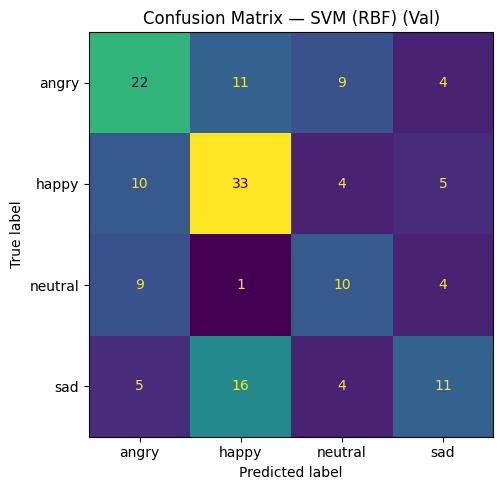


Best model on val: SVM (RBF)


In [9]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_v)
    uar  = recall_score(y_v, pred, average='macro')
    acc  = accuracy_score(y_v, pred)
    f1   = f1_score(y_v, pred, average='macro')
    print(f"{name:30s} | UAR={uar:.3f} | Acc={acc:.3f} | F1={f1:.3f}")
    return model, pred

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)":           SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
}

print(f"{'Model':30s} | UAR   | Acc   | F1")
print("-" * 55)

results = {}
for name, model in models.items():
    m, pred = evaluate(name, model, X_train_sc, y_train_enc, X_val_sc, y_val_enc)
    results[name] = (m, pred)

best_name = max(results, key=lambda n: recall_score(y_val_enc, results[n][1], average='macro'))
best_pred = results[best_name][1]

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_val_enc, best_pred),
    display_labels=le.classes_
).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} (Val)")
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=150)
plt.show()

print(f"\nBest model on val: {best_name}")

In [10]:
X_tr = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr = torch.tensor(y_train_enc, dtype=torch.long)
X_v  = torch.tensor(X_val_sc,   dtype=torch.float32)
y_v  = torch.tensor(y_val_enc,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MLP(86, 4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_uar, best_epoch = 0, 0
for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_v.to(device)).argmax(dim=1).cpu().numpy()
    uar = recall_score(y_val_enc, preds, average='macro')
    if uar > best_uar:
        best_uar = uar
        best_epoch = epoch + 1

print(f"Best Val UAR: {best_uar:.3f} at epoch {best_epoch}")
acc = accuracy_score(y_val_enc, preds)
f1  = f1_score(y_val_enc, preds, average='macro')
print(f"Final Val    | UAR={best_uar:.3f} | Acc={acc:.3f} | F1={f1:.3f}")

print("\n--- Baseline Summary (val UAR) ---")
for name, (_, pred) in results.items():
    print(f"{name:30s} | UAR={recall_score(y_val_enc, pred, average='macro'):.3f}")
print(f"{'MLP':30s} | UAR={best_uar:.3f}")
print("\nConclusion: handcrafted features alone are not adequate for SER.")

mlp_val_uar = best_uar

Best Val UAR: 0.493 at epoch 13
Final Val    | UAR=0.493 | Acc=0.456 | F1=0.438

--- Baseline Summary (val UAR) ---
Logistic Regression            | UAR=0.422
SVM (RBF)                      | UAR=0.459
Random Forest                  | UAR=0.395
MLP                            | UAR=0.493

Conclusion: handcrafted features alone are not adequate for SER.


# Baseline — Hard Samples Analysis


In [11]:

best_clf_pred = results[best_name][1]
cm_base = confusion_matrix(y_val_enc, best_clf_pred)
print(f"Baseline confusion structure ({best_name}, val):")
for i, emo in enumerate(le.classes_):
    most_confused = le.classes_[[j for j in cm_base[i].argsort()[::-1] if j != i][0]]
    print(f"  {emo:8s}: recall={cm_base[i][i] / cm_base[i].sum():.2f} "
          f"-> most confused with {most_confused}")

feat_idx = {'f0_mean': 80, 'rms_mean': 82, 'zcr_mean': 84}
feat_df = pd.DataFrame(X_train[:, list(feat_idx.values())], columns=list(feat_idx))
feat_df['emotion'] = y_train

print("\nMean acoustic features per emotion (train, raw units):")
print(feat_df.groupby('emotion').mean().round(3))

for a, b in [('neutral', 'sad'), ('angry', 'happy')]:
    diff = (feat_df[feat_df.emotion == a].mean(numeric_only=True)
            - feat_df[feat_df.emotion == b].mean(numeric_only=True)).round(3)
    print(f"\n{a} - {b} (positive = higher in {a}):")
    print(diff)

Baseline confusion structure (SVM (RBF), val):
  angry   : recall=0.48 -> most confused with happy
  happy   : recall=0.63 -> most confused with angry
  neutral : recall=0.42 -> most confused with angry
  sad     : recall=0.31 -> most confused with happy

Mean acoustic features per emotion (train, raw units):
         f0_mean  rms_mean  zcr_mean
emotion                             
angry    229.932     0.061     0.145
happy    240.715     0.059     0.162
neutral  171.314     0.066     0.129
sad      211.457     0.062     0.140

neutral - sad (positive = higher in neutral):
f0_mean    -40.143
rms_mean     0.004
zcr_mean    -0.011
dtype: float64

angry - happy (positive = higher in angry):
f0_mean    -10.783
rms_mean     0.002
zcr_mean    -0.017
dtype: float64


# SSL


`facebook/wav2vec2-xls-r-300m`

In [12]:
EMOTIONS = ['angry', 'happy', 'neutral', 'sad']
EMO2IDX  = {e: i for i, e in enumerate(EMOTIONS)}

model_e2v = AutoModel(model="emotion2vec/emotion2vec_plus_base", hub="hf")


def get_emotion2vec_embedding(filepath):
    res = model_e2v.generate(filepath, output_dir=None, granularity="utterance", extract_embedding=True)
    return res[0]['feats']

sample_path = f"{CLIPS_DIR}/{train_df.iloc[0]['filename']}"
emb = get_emotion2vec_embedding(sample_path)
print("Embedding shape:", np.array(emb).shape)

funasr version: 1.3.9.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.3.9


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_base/snapshots/b318240bfe67db81a8c572ecb37ce9c3759b81c9/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_base/snapshots/b318240bfe67db81a8c572ecb37ce9c3759b81c9/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_base/snapshots/b318240bfe67db81a8c572ecb37ce9c3759b81c9/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_base/snapshots/b318240bfe67db81a8c572ecb37ce9c3759b81c9/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/huggingface/hub/models--emotion2vec--emotion2vec_plus_base/snapshots/b318

rtf_avg: 0.739: 100%|██████████| 1/1 [00:01<00:00,  1.28s/it]                                                                                      

Embedding shape: (768,)


In [14]:
warnings.filterwarnings('ignore')
logging.getLogger("funasr").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)
os.environ["FUNASR_LOG_LEVEL"] = "ERROR"
import contextlib
import _io
def extract_e2v(dataframe, clips_dir):
    features, labels = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        path = f"{clips_dir}/{row['filename']}"
        with contextlib.redirect_stdout(_io.StringIO()), contextlib.redirect_stderr(_io.StringIO()):
            emb = model_e2v.generate(path, output_dir=None, granularity="utterance",
                                     extract_embedding=True, disable_pbar=True)
        features.append(np.array(emb[0]['feats']))
        labels.append(EMO2IDX[row['emotion']])
    return np.array(features), np.array(labels)


print("Extracting train...")
X_tr_e2v, y_tr_e2v = extract_e2v(train_df, CLIPS_DIR)
print("Extracting val...")
X_v_e2v,  y_v_e2v  = extract_e2v(val_df,   CLIPS_DIR)
print("Extracting test...")
X_te_e2v, y_te_e2v = extract_e2v(test_df,  CLIPS_DIR)

print("Shapes:", X_tr_e2v.shape, X_v_e2v.shape, X_te_e2v.shape)

X_tr_t = torch.tensor(X_tr_e2v, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_e2v, dtype=torch.long)
X_v_t  = torch.tensor(X_v_e2v,  dtype=torch.float32)
X_te_t = torch.tensor(X_te_e2v, dtype=torch.float32)

train_loader_e2v = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

clf = nn.Sequential(
    nn.Linear(768, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 4)
).to(device)

opt = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-2)

best_uar_e2v, best_state_e2v = 0, None
for epoch in range(30):
    clf.train()
    for xb, yb in train_loader_e2v:
        xb, yb = xb.to(device), yb.to(device)
        loss = nn.CrossEntropyLoss()(clf(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()

    clf.eval()
    with torch.no_grad():
        preds_v = clf(X_v_t.to(device)).argmax(dim=1).cpu().numpy()
    uar = recall_score(y_v_e2v, preds_v, average='macro')
    if uar > best_uar_e2v:
        best_uar_e2v   = uar
        best_state_e2v = {k: v.clone() for k, v in clf.state_dict().items()}
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Val UAR={uar:.3f}")

clf.load_state_dict(best_state_e2v)
clf.eval()
with torch.no_grad():
    preds_te = clf(X_te_t.to(device)).argmax(dim=1).cpu().numpy()

test_uar_e2v = recall_score(y_te_e2v, preds_te, average='macro')
print()
print(f"Best Val UAR (emotion2vec+): {best_uar_e2v:.3f}")
print(f"Test UAR (emotion2vec+ task transfer): {test_uar_e2v:.3f}")

Extracting train...


100%|██████████| 613/613 [00:16<00:00, 36.72it/s]


Extracting val...


100%|██████████| 158/158 [00:03<00:00, 40.30it/s]


Extracting test...


100%|██████████| 181/181 [00:04<00:00, 41.31it/s]


Shapes: (613, 768) (158, 768) (181, 768)
Epoch 05 | Val UAR=0.529
Epoch 10 | Val UAR=0.521
Epoch 15 | Val UAR=0.511
Epoch 20 | Val UAR=0.544
Epoch 25 | Val UAR=0.528
Epoch 30 | Val UAR=0.519

Best Val UAR (emotion2vec+): 0.554
Test UAR (emotion2vec+ task transfer): 0.589


In [15]:
CLIPS_DIR = "/kaggle/working/clips"
EMOTIONS   = ['angry', 'happy', 'neutral', 'sad']
EMO2IDX    = {e: i for i, e in enumerate(EMOTIONS)}
MODEL_NAME = "facebook/wav2vec2-xls-r-300m"

class SERDataset(Dataset):
    def __init__(self, dataframe, clips_dir, feature_extractor):
        self.df = dataframe.reset_index(drop=True)
        self.clips_dir = clips_dir
        self.fe = feature_extractor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, _ = librosa.load(f"{self.clips_dir}/{row['filename']}", sr=16000)
        inputs = self.fe(y, sampling_rate=16000, return_tensors="pt", padding=True)
        return inputs.input_values.squeeze(0), EMO2IDX[row['emotion']]

def collate_fn(batch):
    waveforms, labels = zip(*batch)
    max_len = max(w.shape[0] for w in waveforms)
    padded  = torch.zeros(len(waveforms), max_len)
    for i, w in enumerate(waveforms):
        padded[i, :w.shape[0]] = w
    return padded, torch.tensor(labels)

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

train_ds = SERDataset(train_df, CLIPS_DIR, feature_extractor)
val_ds   = SERDataset(val_df,   CLIPS_DIR, feature_extractor)
test_ds  = SERDataset(test_df,  CLIPS_DIR, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, collate_fn=collate_fn)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    label2id={e: i for i, e in enumerate(EMOTIONS)},
    id2label={i: e for i, e in enumerate(EMOTIONS)},
    ignore_mismatched_sizes=True
)

for param in model.wav2vec2.parameters():
    param.requires_grad = False
for layer in model.wav2vec2.encoder.layers[-6:]:
    for param in layer.parameters():
        param.requires_grad = True

device    = torch.device('cuda')
model     = model.to(device)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-2
)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    all_preds, all_labels = [], []
    with torch.set_grad_enabled(train):
        for xb, yb in tqdm(loader, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            out  = model(xb).logits
            loss = nn.CrossEntropyLoss()(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    uar = recall_score(all_labels, all_preds, average='macro')
    return uar

best_uar, best_state = 0, None
for epoch in range(10):
    train_uar = run_epoch(train_loader, train=True)
    val_uar   = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch+1:02d} | Train UAR={train_uar:.3f} | Val UAR={val_uar:.3f}")
    if val_uar > best_uar:
        best_uar   = val_uar
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
model.to(device)
test_uar = run_epoch(test_loader, train=False)
print(f"\nBest Val UAR: {best_uar:.3f}")
print(f"Test UAR (wav2vec2-xls-r language transfer): {test_uar:.3f}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch 07 | Train UAR=0.679 | Val UAR=0.432


Epoch 08 | Train UAR=0.660 | Val UAR=0.555


Epoch 09 | Train UAR=0.689 | Val UAR=0.528


Epoch 10 | Train UAR=0.696 | Val UAR=0.580



Best Val UAR: 0.580
Test UAR (wav2vec2-xls-r language transfer): 0.661


In [16]:
w2v_ce_val_uar, w2v_ce_test_uar = best_uar, test_uar

# Ablation

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.3),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
])

class SERDatasetAug(SERDataset):
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, _ = librosa.load(f"{self.clips_dir}/{row['filename']}", sr=16000)
        y = augment(y, sample_rate=16000)
        inputs = self.fe(y, sampling_rate=16000, return_tensors="pt", padding=True)
        return inputs.input_values.squeeze(0), EMO2IDX[row['emotion']]

feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-xls-r-300m")

train_ds_aug = SERDatasetAug(train_df, CLIPS_DIR, feature_extractor)
train_loader_aug = DataLoader(train_ds_aug, batch_size=8, shuffle=True, collate_fn=collate_fn)

configs = {
    "CE  | no aug":   (nn.CrossEntropyLoss(), val_loader),
    "FL  | no aug":   (FocalLoss(gamma=2.0),  val_loader),
    "CE  | aug":      (nn.CrossEntropyLoss(), val_loader),
    "FL  | aug":      (FocalLoss(gamma=2.0),  val_loader),
}

use_aug = {"CE  | aug": True, "FL  | aug": True,
           "CE  | no aug": False, "FL  | no aug": False}

print(f"{'Config':20s} | Best Val UAR | Test UAR")
print("-" * 50)

ablation_results = {}
for name, (criterion, _) in configs.items():
    model_abl = AutoModelForAudioClassification.from_pretrained(
        "facebook/wav2vec2-xls-r-300m",
        num_labels=4,
        ignore_mismatched_sizes=True
    ).to(device)

    for param in model_abl.wav2vec2.parameters():
        param.requires_grad = False
    for layer in model_abl.wav2vec2.encoder.layers[-6:]:
        for param in layer.parameters():
            param.requires_grad = True

    opt_abl = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model_abl.parameters()),
        lr=1e-4, weight_decay=1e-2
    )

    loader = train_loader_aug if use_aug[name] else train_loader

    best_v, best_st = 0, None
    for epoch in range(8):
        model_abl.train()
        for xb, yb in tqdm(loader, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model_abl(xb).logits, yb)
            opt_abl.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model_abl.parameters(), 1.0)
            opt_abl.step()

        model_abl.eval()
        with torch.no_grad():
            preds = []
            for xb, yb in val_loader:
                preds.extend(model_abl(xb.to(device)).logits.argmax(dim=1).cpu().numpy())
        uar = recall_score(y_val_enc, preds, average='macro')
        if uar > best_v:
            best_v  = uar
            best_st = {k: v.cpu().clone() for k, v in model_abl.state_dict().items()}

    model_abl.load_state_dict(best_st)
    model_abl.to(device).eval()
    with torch.no_grad():
        preds_te = []
        for xb, yb in test_loader:
            preds_te.extend(model_abl(xb.to(device)).logits.argmax(dim=1).cpu().numpy())
    test_uar = recall_score(y_test_enc, preds_te, average='macro')
    ablation_results[name] = (best_v, test_uar)
    print(f"{name:20s} | {best_v:.3f}        | {test_uar:.3f}")

Config               | Best Val UAR | Test UAR
--------------------------------------------------


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CE  | no aug         | 0.577        | 0.598


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

...

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CE  | aug            | 0.450        | 0.477


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FL  | aug            | 0.607        | 0.600


# Ablation — Freezing Depth


In [18]:
def train_w2v_freeze(n_unfrozen, criterion, epochs=6):
    m = AutoModelForAudioClassification.from_pretrained(
        "facebook/wav2vec2-xls-r-300m", num_labels=4, ignore_mismatched_sizes=True
    ).to(device)
    for p in m.wav2vec2.parameters():
        p.requires_grad = False
    if n_unfrozen > 0:
        for layer in m.wav2vec2.encoder.layers[-n_unfrozen:]:
            for p in layer.parameters():
                p.requires_grad = True

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()), lr=1e-4, weight_decay=1e-2
    )

    best_v, best_st = 0, None
    for _ in range(epochs):
        m.train()
        for xb, yb in tqdm(train_loader, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(m(xb).logits, yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        m.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in val_loader:
                preds.extend(m(xb.to(device)).logits.argmax(dim=1).cpu().numpy())
        uar = recall_score(y_val_enc, preds, average='macro')
        if uar > best_v:
            best_v  = uar
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_st); m.to(device).eval()
    with torch.no_grad():
        preds_te = []
        for xb, _ in test_loader:
            preds_te.extend(m(xb.to(device)).logits.argmax(dim=1).cpu().numpy())
    return best_v, recall_score(y_test_enc, preds_te, average='macro')

freeze_results = {}
print(f"{'Unfrozen top blocks':22s} | Val UAR | Test UAR")
print("-" * 48)
for n in [0, 3, 6, 12]:
    v, t = train_w2v_freeze(n, FocalLoss(gamma=2.0))
    freeze_results[n] = (v, t)
    print(f"{n:<22d} | {v:.3f}   | {t:.3f}")

Unfrozen top blocks    | Val UAR | Test UAR
------------------------------------------------


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0                      | 0.268   | 0.258


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

...

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


6                      | 0.522   | 0.557


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


12                     | 0.543   | 0.589


# Results

FULL RESULTS SUMMARY

Model                                    | Val UAR | Test UAR
------------------------------------------------------------
Logistic Regression (MFCC)               | 0.422   | -
SVM (RBF) (MFCC)                         | 0.459   | -
Random Forest (MFCC)                     | 0.395   | -
MLP (MFCC)                               | 0.493   | -
wav2vec2-xls-r (CE, frozen-6)            | 0.580   | 0.661
emotion2vec+ (frozen, MLP head)          | 0.554   | 0.589
wav2vec2-xls-r CE  | no aug              | 0.577   | 0.598
wav2vec2-xls-r FL  | no aug              | 0.466   | 0.544
wav2vec2-xls-r CE  | aug                 | 0.450   | 0.477
wav2vec2-xls-r FL  | aug                 | 0.607   | 0.600

Best model (by Val UAR): wav2vec2-xls-r [FL  | aug]
Val UAR: 0.607 | Test UAR: 0.600
(sanity) Test UAR of the used model = 0.600


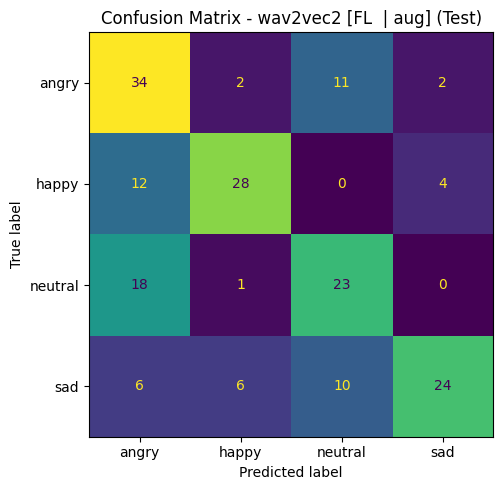


Hard samples analysis:
  angry   : recall=0.69 - most confused with: neutral
  happy   : recall=0.64 - most confused with: angry
  neutral : recall=0.55 - most confused with: angry
  sad     : recall=0.52 - most confused with: neutral


In [22]:
print("=" * 60)
print("FULL RESULTS SUMMARY")
print("=" * 60)
print()
print(f"{'Model':40s} | Val UAR | Test UAR")
print("-" * 60)
for name, (_, pred) in results.items():
    print(f"{name + ' (MFCC)':40s} | {recall_score(y_val_enc, pred, average='macro'):.3f}   | -")
print(f"{'MLP (MFCC)':40s} | {mlp_val_uar:.3f}   | -")
print(f"{'wav2vec2-xls-r (CE, frozen-6)':40s} | {w2v_ce_val_uar:.3f}   | {w2v_ce_test_uar:.3f}")
print(f"{'emotion2vec+ (frozen, MLP head)':40s} | {best_uar_e2v:.3f}   | {test_uar_e2v:.3f}")
for name, (v, t) in ablation_results.items():
    print(f"{'wav2vec2-xls-r ' + name:40s} | {v:.3f}   | {t:.3f}")

best_model_name = max(ablation_results, key=lambda k: ablation_results[k][0])
best_val_uar, best_test_uar = ablation_results[best_model_name]
print()
print(f"Best model (by Val UAR): wav2vec2-xls-r [{best_model_name}]")
print(f"Val UAR: {best_val_uar:.3f} | Test UAR: {best_test_uar:.3f}")

if 'ablation_preds' in globals() and best_model_name in ablation_preds:
    preds_final = ablation_preds[best_model_name]
else:
    model_abl.to(device).eval()
    with torch.no_grad():
        preds_final = []
        for xb, yb in test_loader:
            preds_final.extend(model_abl(xb.to(device)).logits.argmax(dim=1).cpu().numpy())
    preds_final = np.array(preds_final)

print(f"(sanity) Test UAR of the used model = {recall_score(y_test_enc, preds_final, average='macro'):.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_enc, preds_final),
    display_labels=le.classes_
).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix - wav2vec2 [{best_model_name}] (Test)")
plt.tight_layout()
plt.savefig('cm_best.png', dpi=150)
plt.show()

print()
print("Hard samples analysis:")
cm = confusion_matrix(y_test_enc, preds_final)
for i, emotion in enumerate(le.classes_):
    total   = cm[i].sum()
    correct = cm[i][i]
    confused = le.classes_[[j for j in cm[i].argsort()[::-1] if j != i][0]]
    print(f"  {emotion:8s}: recall={correct/total:.2f} - most confused with: {confused}")

In [23]:
print("=" * 60)
print("CONCLUSIONS")
print("=" * 60)

final = {f"wav2vec2 {name}": t for name, (v, t) in ablation_results.items()}
final["emotion2vec+ MLP"]     = test_uar_e2v
final["wav2vec2 CE (single)"] = w2v_ce_test_uar
if 'freeze_results' in globals():
    for n, (v, t) in freeze_results.items():
        final[f"wav2vec2 FL | unfrozen-{n}"] = t

print()
print("Final ranking by Test UAR:")
for i, (name, uar) in enumerate(sorted(final.items(), key=lambda x: -x[1]), 1):
    print(f"  {i:2d}. {name:32s} Test UAR={uar:.3f}")

CONCLUSIONS

Final ranking by Test UAR:
   1. wav2vec2 CE (single)             Test UAR=0.661
   2. wav2vec2 FL  | aug               Test UAR=0.600
   3. wav2vec2 CE  | no aug            Test UAR=0.598
   4. wav2vec2 FL | unfrozen-12        Test UAR=0.589
   5. emotion2vec+ MLP                 Test UAR=0.589
   6. wav2vec2 FL | unfrozen-6         Test UAR=0.557
   7. wav2vec2 FL  | no aug            Test UAR=0.544
   8. wav2vec2 CE  | aug               Test UAR=0.477
   9. wav2vec2 FL | unfrozen-3         Test UAR=0.348
  10. wav2vec2 FL | unfrozen-0         Test UAR=0.258
